## Weighted Least Squares

We have a dataset $(x-y- \sigma_y)$ and a general linear model (see *Normal_Equation.ipynb*). If we weigh residuals with $\sigma_y$ we can write the sum of squared residuals as:

$$
    \sum_{j = 0}^{N - 1} \, \left( \frac{y_j - \sum_{k = 0}^{d - 1} \, \theta_{k} \, f_{k}(x_j)}{\sigma_{y, j}} \right) ^ 2
$$

In vectorial form:

$$
    \left( \vec{y} - \mathcal{X} \, \vec{\theta} \right)^{t} \, \mathcal{W} \, \left( \vec{y} - \mathcal{X} \, \vec{\theta} \right)
$$

Where $\mathcal{W}$ is the diagonal weight matrix:

$$
    \mathcal{W} = \, \left( \frac{1}{\sigma_{y, 0} ^ 2} \, \frac{1}{\sigma_{y, 1} ^ 2}, \frac{1}{\sigma_{y, 2} ^ 2}, \cdots, \frac{1}{\sigma_{y, N - 1} ^ 2} \right)
$$

$$
    \mathcal{W}_{jj} = \frac{1}{\sigma_{y, j} ^ 2} \quad \text{for} \quad j = 0, 1, 2, \cdots, N - 1
$$

The normal equation can handle uncertainties of $y$. The closed form solution is:

$$
    \vec{\theta} = \left( \mathcal{X}^{t} \, \mathcal{W} \, \mathcal{X} \right)^{-1} \, \mathcal{X}^{t} \, \mathcal{W} \, \vec{y}
$$

This matrix:

$$
    \left( \mathcal{X}^{t} \, \mathcal{W} \, \mathcal{X} \right)^{-1}
$$

Is the covariance matrix of estimated parameters, assuming the measurement errors are independent.

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

### Exponential decay

Let's fit a dataset with $\sigma_N$ errors using an exponential model:

$$
    N(t) = N_0 \, e^{- k \, t}
$$

Where $N_0$ and $k$ are unknown. We can linearize this model by computing its logarithimic:

$$
    \ln{N} = \ln{N_0} - k \, t
$$

So we can easily set:

\begin{aligned}
    y &= \ln{N} \\
    q &= \ln{N_0}
\end{aligned}

To get a linear model:

$$
    y = q - k \, t
$$

Errors $\sigma_y$ must be transformed accordingly:

$$
    N \pm \sigma_N \, \longrightarrow \, \ln{N} \pm \frac{\sigma_N}{N}
$$

So:

$$
    \sigma_y = \frac{\sigma_N}{N}
$$

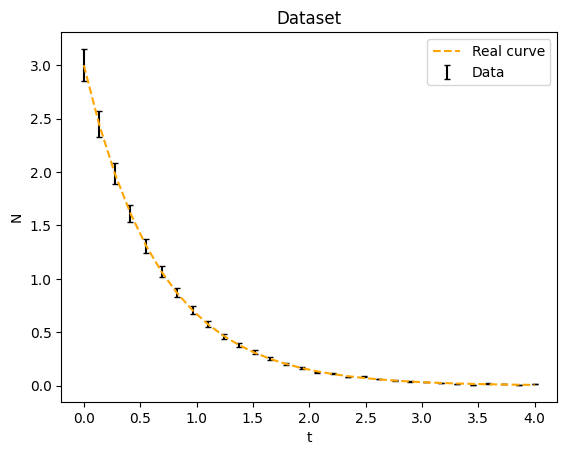

In [2]:
# Synthetic dataset
t = np.linspace(0.0, 4.0, 30) # 30 points
N = np.abs(3.0 * np.exp(- 1.5 * t) + np.random.normal(loc = 0.0, scale = 0.005, size = len(t))) # Some little noise
sigma_N = N / 20.0 # 5% of N

plt.title('Dataset')
plt.errorbar(x = t, y = N, yerr = sigma_N, fmt = 'None', capsize = 2, color = 'black', label = 'Data')
plt.plot(t, np.abs(3.0 * np.exp(- 1.5 * t)), linestyle = '--', color = 'orange', label = 'Real curve')
plt.xlabel('t')
plt.ylabel('N')
plt.legend(loc = 'best')
plt.show()

Let's compute $y$ and $\sigma_y$:

$$
    y = \ln{N} \quad \sigma_y = \frac{\sigma_N}{N}
$$

In [3]:
y = np.log(N)
sigma_y = sigma_N / N
y, sigma_y # All 0.05

(array([ 1.09940451,  0.89435477,  0.6868249 ,  0.47806264,  0.27095694,
         0.06444776, -0.13935149, -0.34633841, -0.55566138, -0.77361566,
        -0.96107374, -1.15821477, -1.3749287 , -1.60158024, -1.78808117,
        -2.07735911, -2.20189703, -2.51329871, -2.4814601 , -2.7606398 ,
        -3.04260698, -3.21517583, -3.34151655, -3.71957912, -3.94742632,
        -4.65488175, -3.82619082, -4.23160781, -4.73241423, -4.26123146]),
 array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
        0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
        0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]))

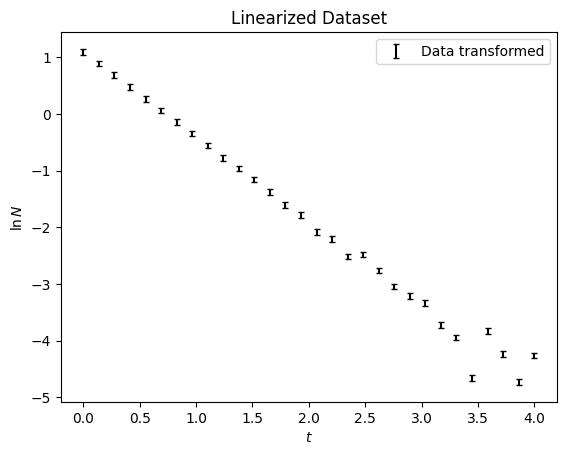

In [4]:
# Data transformation plot
plt.title('Linearized Dataset')
plt.errorbar(x = t, y = y, yerr = sigma_y, fmt = 'None', capsize = 2, color = 'black', label = 'Data transformed')
plt.xlabel(r'$t$')
plt.ylabel(r'$\ln{N}$')
plt.legend(loc = 'best')
plt.show()

Let's compute the weight matrix $\mathcal{W}$. It'll be a constant diagonal matrix:

$$
    \mathcal{W}_{jj} = \frac{1}{\sigma_y ^ 2}
$$

In [5]:
W = np.diag(1 / (sigma_y ** 2))
W

array([[400.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0., 400.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0., 400.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0., 400.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0., 400.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0., 

Let's compute the Design Matrix $\mathcal{X}$:

$$
    \mathcal{X}_{j,:} = \left( 1, \, - t_j \right)
$$

In [6]:
X = np.column_stack((np.ones_like(t), - t))
X

array([[ 1.        , -0.        ],
       [ 1.        , -0.13793103],
       [ 1.        , -0.27586207],
       [ 1.        , -0.4137931 ],
       [ 1.        , -0.55172414],
       [ 1.        , -0.68965517],
       [ 1.        , -0.82758621],
       [ 1.        , -0.96551724],
       [ 1.        , -1.10344828],
       [ 1.        , -1.24137931],
       [ 1.        , -1.37931034],
       [ 1.        , -1.51724138],
       [ 1.        , -1.65517241],
       [ 1.        , -1.79310345],
       [ 1.        , -1.93103448],
       [ 1.        , -2.06896552],
       [ 1.        , -2.20689655],
       [ 1.        , -2.34482759],
       [ 1.        , -2.48275862],
       [ 1.        , -2.62068966],
       [ 1.        , -2.75862069],
       [ 1.        , -2.89655172],
       [ 1.        , -3.03448276],
       [ 1.        , -3.17241379],
       [ 1.        , -3.31034483],
       [ 1.        , -3.44827586],
       [ 1.        , -3.5862069 ],
       [ 1.        , -3.72413793],
       [ 1.        ,

Now we solve the problem easily

In [7]:
gram = (X.T @ W) @ X
Aux = ((X.T @ W) @ y)
Cov = np.linalg.inv(gram) # Covariance matrix
Cov

array([[3.17204301e-04, 1.16935484e-04],
       [1.16935484e-04, 5.84677419e-05]])

In [8]:
# Estimate errors
errq1, errk1 = np.sqrt(np.diag(Cov))
errq1, errk1

(np.float64(0.01781023023644751), np.float64(0.007646420203957138))

In [9]:
q_opt, k_opt = Cov @ Aux # Solution 1
q_opt, k_opt

(np.float64(1.0539191651184907), np.float64(1.4638275770260667))

In [10]:
# Relative errors
100 * errq1 / q_opt, 100 * errk1 / k_opt

(np.float64(1.6899047693515594), np.float64(0.5223579828637821))

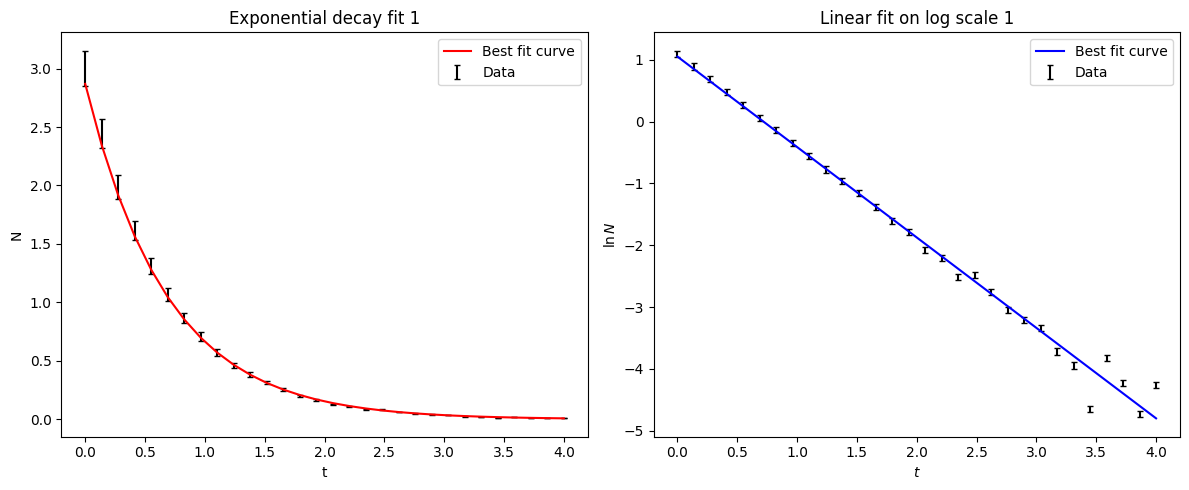

In [11]:
# Plotting results
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize = (12, 5))

ax_left.errorbar(x = t, y = N, yerr = sigma_N, fmt = 'None', capsize = 2, color = 'black', label = 'Data')
ax_left.plot(t, np.exp(q_opt) * np.exp(- k_opt * t), color = 'red', linewidth = 1.5, label = 'Best fit curve')
ax_left.set_xlabel('t')
ax_left.set_ylabel('N')
ax_left.set_title('Exponential decay fit 1')
ax_left.legend(loc = 'best')

ax_right.errorbar(x = t, y = y, yerr = sigma_y, fmt = 'None', capsize = 2, color = 'black', label = 'Data')
ax_right.plot(t, q_opt - k_opt * t, color = 'blue', linewidth = 1.5, label = 'Best fit curve')
ax_right.set_xlabel(r'$t$')
ax_right.set_ylabel(r'$\ln{N}$')
ax_right.set_title('Linear fit on log scale 1')
ax_right.legend(loc = 'best')

plt.tight_layout()
plt.show()

A closed form solution exists for a straight line $y = m \, x + q $. WLS problem. Define the weighted sums:

$$
    S = \sum_{i=1}^N w_i\quad
    S_x = \sum_{i=1}^N w_i x_i\quad
    S_y = \sum_{i=1}^N w_i y_i\quad
    S_{xx} = \sum_{i=1}^N w_i x_i^2\quad
    S_{xy} = \sum_{i=1}^N w_i x_i y_i
$$

Then:

$$
    \mathcal{X}^T \mathcal{W} \mathcal{X} = \begin{pmatrix}
        S & S_x \\
        S_x & S_{xx}
    \end{pmatrix},\qquad
    \mathcal{X}^T \mathcal{W} \, \vec{y} = \begin{pmatrix}
        S_y \\
        S_{xy}
    \end{pmatrix}
$$

The normal equation becomes:

$$
    \begin{cases}
    S\, q + S_x\, m = S_y,\\[4pt]
    S_x\, q + S_{xx}\, m = S_{xy}
    \end{cases}
$$

Solving for $q$ and $m$ yields:

$$
    q = \frac{S_y S_{xx} - S_x S_{xy}}{S S_{xx} - S_x^2} \qquad
    m = \frac{S S_{xy} - S_x S_y}{S S_{xx} - S_x^2}
$$

The covariance matrix of the estimated parameters is:

$$
    \begin{pmatrix}
        S_{xx} & -S_x \\
        -S_x & S
    \end{pmatrix}
$$

So:
$$
    \operatorname{var}(q) = \frac{S_{xx}}{S S_{xx} - S_x^2},\quad
    \operatorname{var}(m) = \frac{S}{S S_{xx} - S_x^2},\quad
    \operatorname{cov}(q,m) = -\frac{S_x}{S S_{xx} - S_x^2}
$$

Let's apply these formulas. We should find the same results above

In [12]:
# Computing q and k using direct formulas
S = gram[0, 0]
Sx = gram[0, 1]
Sxx = gram[1, 1]
Sy, Sxy = Aux

k_opt2 = (S * Sxy - Sx * Sy) / (S * Sxx - Sx ** 2)
q_opt2 = (Sy * Sxx - Sx * Sxy) / (S * Sxx - Sx ** 2)
q_opt2, k_opt2 # Solution 2

(np.float64(1.05391916511849), np.float64(1.4638275770260665))

In [13]:
# Difference is tiny, actually
q_opt - q_opt2, k_opt - k_opt2

(np.float64(6.661338147750939e-16), np.float64(2.220446049250313e-16))

In [14]:
# Computing errors
errq2 = np.sqrt(Sxx / (S * Sxx - Sx ** 2))
errk2 = np.sqrt(S / (S * Sxx - Sx ** 2))
errq2, errk2

(np.float64(0.017810230236447507), np.float64(0.007646420203957137))

In [15]:
# Same errors found
errq1 - errq2, errk1 - errk2

(np.float64(3.469446951953614e-18), np.float64(8.673617379884035e-19))

If $\mathcal{W}$ is a constant diagonal matrix $\sigma_W$ (as in our case), the WLS problem reduces to OLS problem:

$$
    \begin{pmatrix} q \\ m \end{pmatrix}
    = \left( \mathcal{X}^T \mathcal{X} \right)^{-1} \mathcal{X}^T \, \vec{y}
$$

And the covariance matrix is given by:

$$
    \frac{1}{\sigma_W} \, \left( \mathcal{X^T} \mathcal{X} \right)^{-1}
$$

Let's see

In [16]:
# OLS formula
q_opt3, k_opt3 = (np.linalg.inv(X.T @ X) @ X.T) @ y
q_opt3, k_opt3 # Solution 3

(np.float64(1.0539191651184878), np.float64(1.4638275770260651))

In [17]:
# Again difference is really tiny
q_opt3 - q_opt, k_opt3 - k_opt

(np.float64(-2.886579864025407e-15), np.float64(-1.5543122344752192e-15))

In [18]:
# Computing errors
errq3, errk3 = np.sqrt(np.diag(1.0 / W[0, 0] * (np.linalg.inv(X.T @ X))))
errq3, errk3

(np.float64(0.017810230236447504), np.float64(0.007646420203957135))

In [19]:
# Same errors again
errq3 - errq1, errk3 - errk1

(np.float64(-6.938893903907228e-18), np.float64(-2.6020852139652106e-18))

Let's use curve_fit() to find the best fit curve. See the comparison

In [20]:
popt, pcov = curve_fit(
    f = lambda var, N0, k: N0 * np.exp(- k * var),
    xdata = t,
    ydata = N,
    sigma = sigma_N,
    absolute_sigma = True,
    p0 = (3.0, - 1.5),
    method = 'lm'
)

popt, np.sqrt(np.diag(pcov)) # q, k, errq, errk

(array([3.06531693, 1.52396481]), array([0.05498922, 0.00789574]))

Which fit is "better"? Let's plot residual and some useful metrics

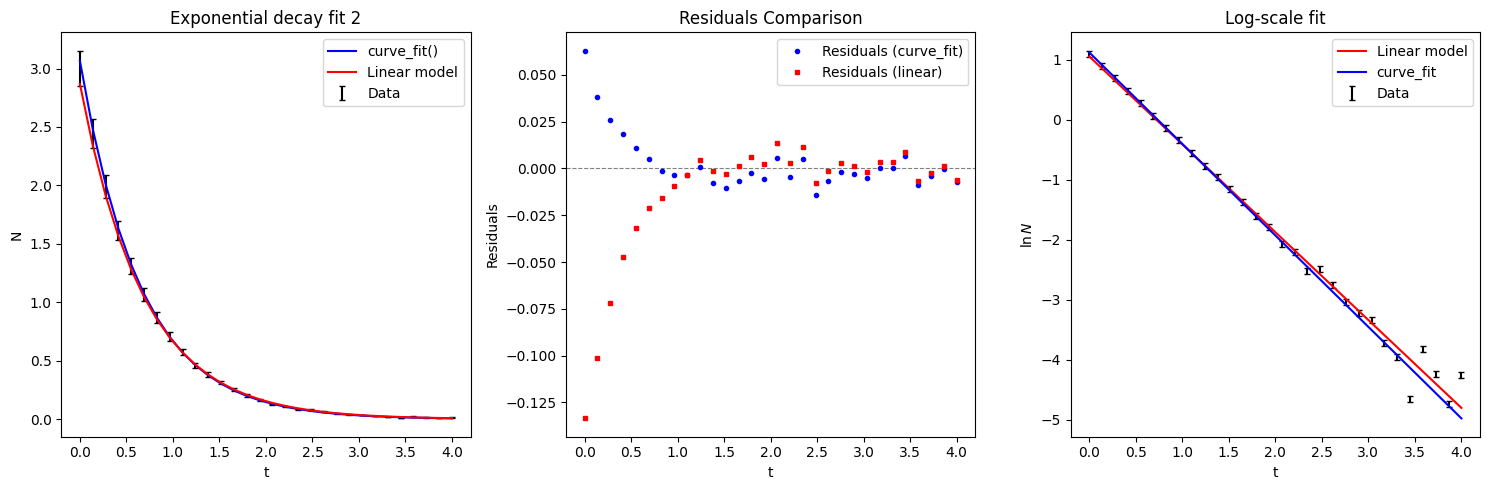

In [21]:
# Compute residuals
residuals_curve_fit = popt[0] * np.exp(-popt[1] * t) - N
residuals_linear_model = np.exp(q_opt) * np.exp(- k_opt * t) - N

fig, (ax_left, ax_mid, ax_right) = plt.subplots(1, 3, figsize = (15, 5))

ax_left.errorbar(t, N, yerr = sigma_N, fmt = 'None', capsize = 2, color = 'black', label = 'Data')
ax_left.plot(t, popt[0] * np.exp(-popt[1] * t), color='blue', label="curve_fit()", linewidth = 1.5)
ax_left.plot(t, np.exp(q_opt) * np.exp(- k_opt * t), color = 'red', label = 'Linear model', linewidth = 1.5)
ax_left.set_xlabel('t')
ax_left.set_ylabel('N')
ax_left.set_title('Exponential decay fit 2')
ax_left.legend(loc = 'best')

ax_mid.axhline(0, color = 'gray', linestyle = '--', linewidth = 0.8)
ax_mid.plot(t, residuals_curve_fit, 'o', color = 'blue', markersize = 3, label = 'Residuals (curve_fit)')
ax_mid.plot(t, residuals_linear_model, 's', color = 'red', markersize = 3, label = 'Residuals (linear)')
ax_mid.set_xlabel('t')
ax_mid.set_ylabel('Residuals')
ax_mid.set_title('Residuals Comparison')
ax_mid.legend(loc = 'best')

ax_right.errorbar(t, y, yerr = sigma_y, fmt = 'None', capsize = 2, color = 'black', label = 'Data')
ax_right.plot(t, q_opt - k_opt * t, color = 'red', linewidth = 1.5, label = 'Linear model')
ax_right.plot(t, np.log(popt[0]) - popt[1] * t, color = 'blue', linewidth = 1.5, label = 'curve_fit')
ax_right.set_xlabel('t')
ax_right.set_ylabel(r'$\ln{N}$')
ax_right.set_title('Log-scale fit')
ax_right.legend(loc = 'best')

plt.tight_layout()
plt.show()

In [22]:
# Computing minimized sum of squared residual with errors (chi squared)
RSS_linear = np.sum((residuals_linear_model / sigma_N) ** 2)
RSS_curve_fit = np.sum((residuals_curve_fit / sigma_N) ** 2)
RSS_linear, RSS_curve_fit # Curve_fit() is slightly better. Errors fully underestimated, actually

(np.float64(518.5849075327192), np.float64(419.61513292811725))

In [23]:
# R^2
ss = np.sum((N - np.mean(N)) ** 2)
r2_linear = 1 - np.sum(residuals_linear_model ** 2) / ss
r2_curve = 1 - np.sum(residuals_curve_fit ** 2) / ss
r2_linear, r2_curve # Curve_fit() is a little better

(np.float64(0.9978949296802403), np.float64(0.9995882279371479))

In [24]:
# Mean Square Error and its square root
MSE_linear = np.mean(residuals_linear_model ** 2)
MSE_curve_fit = np.mean(residuals_curve_fit ** 2)
MSE_linear, np.sqrt(MSE_linear), MSE_curve_fit, np.sqrt(MSE_curve_fit) # Curve_fit() is better

(np.float64(0.0012658550282377118),
 np.float64(0.03557885647737588),
 np.float64(0.00024761345564396845),
 np.float64(0.01573573816647851))

In [25]:
# Mean Absolute Error
MAE_linear = np.mean(np.abs(residuals_linear_model))
MAE_curve_fit = np.mean(np.abs(residuals_curve_fit))
MAE_linear, MAE_curve_fit # Curve_fit() is better

(np.float64(0.017644878222636197), np.float64(0.009254485844776401))

Overall, both fits work. curve_fit() is a little better, though the gap is not large.

In [28]:
# q and k differences
popt[0] - np.exp(q_opt), popt[1] - k_opt

(np.float64(0.19644422788930882), np.float64(0.06013723195858711))